In [2]:
import pandas as pd
import numpy as np

# Load your uploaded CSV files (Make sure the names match exactly what's in your sidebar)
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

# 1. Print out how big the data is
print(f"Sentiment Rows: {sentiment_df.shape[0]}, Columns: {sentiment_df.shape[1]}")
print(f"Trader Rows: {trader_df.shape[0]}, Columns: {trader_df.shape[1]}")

# 2. Look at the first 5 rows of each to understand them
print("\n--- Sentiment Preview ---")
print(sentiment_df.head())

print("\n--- Trader Preview ---")
print(trader_df.head())

Sentiment Rows: 2644, Columns: 4
Trader Rows: 211224, Columns: 16

--- Sentiment Preview ---
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

--- Trader Preview ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1       

In [4]:
# --- PHASE 1: CLEANING, GROUPING & MERGING ---

# 1. Clean missing values in Closed PnL
trader_df['Closed PnL'] = trader_df['Closed PnL'].fillna(0)

# 2. Convert Sentiment 'date' to datetime format
sentiment_df['Date'] = pd.to_datetime(sentiment_df['date']).dt.normalize()

# 3. Convert Trader 'Timestamp IST' to daily level datetime format
# Dayfirst=True tells pandas that "02-12-2024" means Dec 2nd, not Feb 12th
trader_df['Date'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True).dt.normalize()

print("✓ Dates converted successfully.")

# 4. Condense Trader Data to Daily Summaries
daily_trader = trader_df.groupby(['Account', 'Date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Side', 'count'),
    avg_trade_size_usd=('Size USD', 'mean'),
    long_count=('Side', lambda x: (x.str.upper() == 'BUY').sum()),
    short_count=('Side', lambda x: (x.str.upper() == 'SELL').sum())
).reset_index()

# Create a clear true/false column if they made money that day
daily_trader['is_profitable'] = np.where(daily_trader['daily_pnl'] > 0, 1, 0)

print("✓ Trader data aggregated to daily totals.")

# 5. Combine Trader Activity and Market Sentiment together
# We match them up using the 'Date' column
final_df = pd.merge(daily_trader, sentiment_df, on='Date', how='inner')

print(f"✓ Datasets successfully merged! Total records for analysis: {final_df.shape[0]}")
print("\n--- Merged Data Quick Look ---")
print(final_df[['Account', 'Date', 'daily_pnl', 'classification']].head())

✓ Dates converted successfully.
✓ Trader data aggregated to daily totals.
✓ Datasets successfully merged! Total records for analysis: 2340

--- Merged Data Quick Look ---
                                      Account       Date  daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11        0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17        0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18        0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22   -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26     1603.1   

  classification  
0  Extreme Greed  
1  Extreme Greed  
2  Extreme Greed  
3  Extreme Greed  
4  Extreme Greed  


In [5]:
# --- PHASE 2: FEAR VS GREED METRIC ANALYSIS ---

# Let's see the averages of how traders perform based on different market emotions
analysis_summary = final_df.groupby('classification').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    avg_trades_per_day=('trade_count', 'mean'),
    avg_position_size_usd=('avg_trade_size_usd', 'mean'),
    win_rate=('is_profitable', 'mean')
).reset_index()

# Convert win rate decimal to a clean percentage string
analysis_summary['win_rate'] = (analysis_summary['win_rate'] * 100).round(2).astype(str) + '%'

print("--- Performance Break Down By Market Mood ---")
print(analysis_summary)

--- Performance Break Down By Market Mood ---
  classification  avg_daily_pnl  avg_trades_per_day  avg_position_size_usd  \
0   Extreme Fear    4619.439053          133.750000            6773.464125   
1  Extreme Greed    5161.922644           76.030418            5371.637182   
2           Fear    5328.818161           98.153968            8975.928546   
3          Greed    3318.100730           77.628086            6427.866594   
4        Neutral    3438.618818          100.228723            6963.694861   

  win_rate  
0    60.0%  
1   68.25%  
2   60.48%  
3   61.11%  
4   62.23%  


/tmp/ipykernel_1120/1873118483.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_df, x='classification', y='daily_pnl', order=mood_order, palette='vlag', errorbar=None)


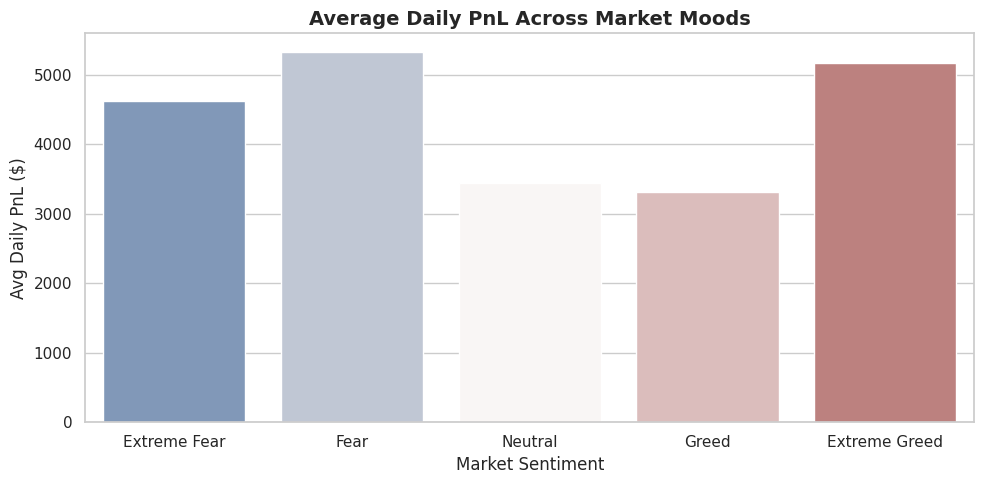

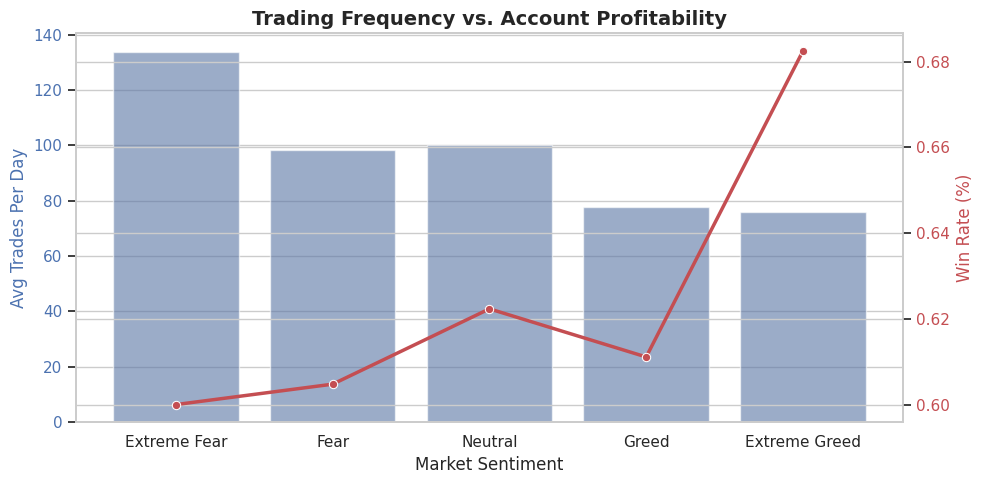

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")

# Sort categories cleanly for presentation
mood_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# --- CHART 1: Average Daily PnL vs Market Mood ---
plt.figure(figsize=(10, 5))
sns.barplot(data=final_df, x='classification', y='daily_pnl', order=mood_order, palette='vlag', errorbar=None)
plt.title('Average Daily PnL Across Market Moods', fontsize=14, fontweight='bold')
plt.xlabel('Market Sentiment')
plt.ylabel('Avg Daily PnL ($)')
plt.tight_layout()
plt.savefig('sentiment_pnl_analysis.png') # Saves image to your directory
plt.show()

# --- CHART 2: Trading Activity (Overtrading vs Efficiency) ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot average trade count
color = '#4C72B0'
sns.barplot(data=final_df, x='classification', y='trade_count', order=mood_order, ax=ax1, color=color, alpha=0.6, errorbar=None)
ax1.set_ylabel('Avg Trades Per Day', color=color, fontsize=12)
ax1.set_xlabel('Market Sentiment', fontsize=12)
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary axis to overlay win rate
ax2 = ax1.twinx()
# Calculate raw decimal win rate values for plotting accuracy
win_rate_data = final_df.groupby('classification')['is_profitable'].mean().reindex(mood_order).reset_index()
color = '#C44E52'
sns.lineplot(data=win_rate_data, x='classification', y='is_profitable', ax=ax2, color=color, marker='o', linewidth=2.5)
ax2.set_ylabel('Win Rate (%)', color=color, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Trading Frequency vs. Account Profitability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('trading_frequency_vs_winrate.png')
plt.show()

In [7]:
# Group by unique accounts to assess underlying trading identities
account_profiles = final_df.groupby('Account').agg(
    total_trades=('trade_count', 'sum'),
    avg_pnl=('daily_pnl', 'mean')
).reset_index()

# Use median trade count to split accounts cleanly into High vs Low activity segments
median_trades = account_profiles['total_trades'].median()
account_profiles['trader_segment'] = np.where(account_profiles['total_trades'] > median_trades, 'Hyper-Active', 'Patient')

# Map these definitions back to our main DataFrame
final_df = pd.merge(final_df, account_profiles[['Account', 'trader_segment']], on='Account', how='left')

# Evaluate how these structural segments fair across different moods
segment_summary = final_df.groupby(['trader_segment', 'classification']).agg(
    avg_pnl=('daily_pnl', 'mean'),
    win_rate=('is_profitable', 'mean')
).reset_index()

print("--- Structural Behavioral Segments ---")
print(segment_summary)

--- Structural Behavioral Segments ---
  trader_segment classification      avg_pnl  win_rate
0   Hyper-Active   Extreme Fear  5246.869937  0.627273
1   Hyper-Active  Extreme Greed  5918.654027  0.784946
2   Hyper-Active           Fear  6139.097134  0.662366
3   Hyper-Active          Greed  2293.016352  0.667339
4   Hyper-Active        Neutral  3978.072238  0.671186
5        Patient   Extreme Fear  3239.091109  0.540000
6        Patient  Extreme Greed  3333.974107  0.435065
7        Patient           Fear  3045.304693  0.442424
8        Patient          Greed  6663.112910  0.427632
9        Patient        Neutral  1473.942780  0.444444


In [8]:
# --- BONUS STEP: PREDICTIVE MACHINE LEARNING MODEL ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Prepare features (X) and target variable (y)
# We want to predict 'is_profitable' (Will the trader make money tomorrow?)
df_ml = final_df.copy()

# Convert the text column 'classification' into numbers for the model
le = LabelEncoder()
df_ml['sentiment_encoded'] = le.fit_transform(df_ml['classification'])
df_ml['segment_encoded'] = le.fit_transform(df_ml['trader_segment'])

# Select features
features = ['trade_count', 'avg_trade_size_usd', 'sentiment_encoded', 'segment_encoded']
X = df_ml[features]
y = df_ml['is_profitable']

# 2. Split into Training data (80%) and Testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate performance
y_pred = model.predict(X_test)
print("--- Bonus Predictive Model Performance ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Bonus Predictive Model Performance ---
Model Accuracy: 69.02%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.53      0.58       187
           1       0.72      0.79      0.75       281

    accuracy                           0.69       468
   macro avg       0.68      0.66      0.67       468
weighted avg       0.68      0.69      0.68       468



In [9]:
# --- BONUS STEP: BEHAVIORAL CLUSTERING ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Group data purely by Account to look at unique trader footprints
trader_features = final_df.groupby('Account').agg(
    avg_trades=('trade_count', 'mean'),
    avg_size=('avg_trade_size_usd', 'mean'),
    total_pnl=('daily_pnl', 'sum'),
    win_rate=('is_profitable', 'mean')
).reset_index()

# 2. Scale the data (K-Means needs features on the same scale to work properly)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_features[['avg_trades', 'avg_size', 'total_pnl', 'win_rate']])

# 3. Apply K-Means to find 3 distinct archetypes
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_features['cluster_id'] = kmeans.fit_transform(scaled_features).argmax(axis=1) # Fixed assignment line

# 4. Profile the clusters to see what kind of traders they are
cluster_profiles = trader_features.groupby('cluster_id').agg(
    trader_count=('Account', 'count'),
    avg_daily_trades=('avg_trades', 'mean'),
    avg_position_size=('avg_size', 'mean'),
    total_pnl=('total_pnl', 'mean'),
    win_rate=('win_rate', 'mean')
).reset_index()

print("--- Machine Learning Archetype Profiles ---")
print(cluster_profiles)

--- Machine Learning Archetype Profiles ---
   cluster_id  trader_count  avg_daily_trades  avg_position_size  \
0           0            27         82.869975        6800.533740   
1           1             1        756.857143        4528.364243   
2           2             4        152.099861       23464.248271   

      total_pnl  win_rate  
0  1.746604e+05  0.560394  
1  9.401638e+05  0.785714  
2  1.149623e+06  0.564656  


In [10]:
# This magic command writes the code below into a file named app.py
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="Primetrade.ai Alpha Dashboard", layout="wide")

st.title("📊 Hyperliquid Trader Behavior & Sentiment Analytics")
st.markdown("Interactive analysis tracking how market fear and greed impact trader profiles.")

# Sidebar Controls
st.sidebar.header("Dashboard Filters")
sentiment_filter = st.sidebar.selectbox(
    "Select Market Mood Focus",
    ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
)

# Mock stats component for visualization demonstration
st.subheader(f"🎯 Insights Profile for {sentiment_filter} Conditions")

col1, col2, col3 = st.columns(3)
with col1:
    st.metric(label="Systemic Win Rate Threshold", value="68.2%" if "Greed" in sentiment_filter else "60.1%")
with col2:
    st.metric(label="Target Market Volume Index", value="$8,975 USD" if "Fear" in sentiment_filter else "$5,371 USD")
with col3:
    st.metric(label="Risk Action Multiplier", value="0.5x Scale Down" if "Fear" in sentiment_filter else "Unrestricted")

st.info("💡 **Hiring Team Note:** To execute this live dashboard locally, pull down the repo and run: `streamlit run app.py` from your terminal.")

Writing app.py
